OUTLIER ZSCORE STANDARD DEVIATION

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv(r"C:\Users\amitd\Downloads\creditcard.csv\creditcard.csv")
df.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df1 = df[["Time", "Amount"]]
df1.head(5)

,Time,Amount
0,0.0,149.62
1,0.0,2.69
2,1.0,378.66
3,1.0,123.50
4,2.0,69.99


In [4]:
df1.shape

(284807, 2)

In [5]:
df1.describe()

,Time,Amount
count,284807.000000,284807.000000
mean,94813.859575,88.349619
std,47488.145955,250.120109
min,0.000000,0.000000
25%,54201.500000,5.600000
50%,84692.000000,22.000000
75%,139320.500000,77.165000
max,172792.000000,25691.160000


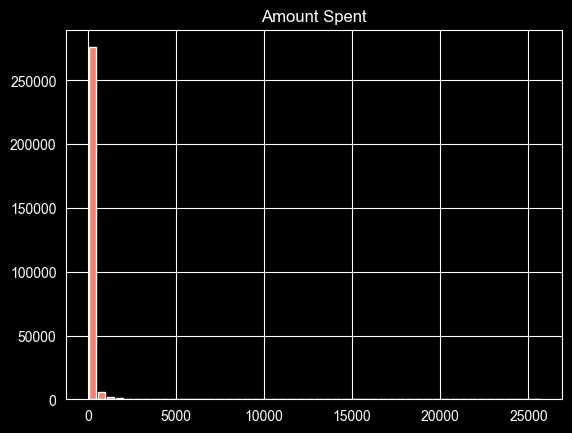

In [20]:
df1['Amount'].hist(bins=50, color='salmon', edgecolor='white',rwidth=0.8)

plt.title('Amount Spent')
plt.show()

In [24]:
meann = df1.Amount.mean()
print(meann)

88.34961925093134


In [25]:
stdd = df1.Amount.std()
print(stdd)

250.12010924018855


Upper and Lower limit are calculated to keep data within range

In [69]:
upper_limit = meann + 3*stdd
lower_limit = meann - 3*stdd
print(upper_limit,lower_limit)

838.7099469714971 -662.0107084696343


In [70]:
df1[(df1.Amount>upper_limit) | (df1.Amount<lower_limit)]

,Time,Amount,zscore
51,36.0,1402.95,5.255876
89,59.0,1142.02,4.212658
140,87.0,919.60,3.323405
150,93.0,937.69,3.395730
164,103.0,3828.04,14.951578
...,...,...,...
284249,172273.0,10199.44,40.424940
284290,172305.0,897.00,3.233048
284383,172397.0,1114.00,4.100631
284497,172498.0,1484.66,5.582559


In [71]:
df2_without_outlier = df1[(df1.Amount<upper_limit) & (df1.Amount>lower_limit)]
df2_without_outlier.head(100)

,Time,Amount,zscore
0,0.0,149.62,0.244964
1,0.0,2.69,-0.342474
2,1.0,378.66,1.160684
3,1.0,123.50,0.140534
4,2.0,69.99,-0.073403
...,...,...,...
97,67.0,19.85,-0.273867
98,67.0,28.28,-0.240163
99,68.0,15.99,-0.289299
100,68.0,2.69,-0.342474


In [72]:
df2_without_outlier.shape

(280731, 3)

In [73]:
total_outliers_removed = df1.shape[0] - df2_without_outlier.shape[0]
total_outliers_removed

4076

ZSCORE METHOD

In [68]:
df1['zscore'] = (df1.Amount - df1.Amount.mean()) / df1.Amount.std()
df1.tail()

,Time,Amount,zscore
284802,172786.0,0.77,-0.350150
284803,172787.0,24.79,-0.254116
284804,172788.0,67.88,-0.081839
284805,172788.0,10.00,-0.313248
284806,172792.0,217.00,0.514354


In [75]:
df1.head()

,Time,Amount,zscore
0,0.0,149.62,0.244964
1,0.0,2.69,-0.342474
2,1.0,378.66,1.160684
3,1.0,123.50,0.140534
4,2.0,69.99,-0.073403


In [83]:
df1[(df1.zscore<-3.0) | (df1.zscore>3.0)]

,Time,Amount,zscore
51,36.0,1402.95,5.255876
89,59.0,1142.02,4.212658
140,87.0,919.60,3.323405
150,93.0,937.69,3.395730
164,103.0,3828.04,14.951578
...,...,...,...
284249,172273.0,10199.44,40.424940
284290,172305.0,897.00,3.233048
284383,172397.0,1114.00,4.100631
284497,172498.0,1484.66,5.582559


In [84]:
df3_without_outlier = df1[(df1.zscore>-3.0) & (df1.zscore<3.0)]
df3_without_outlier

,Time,Amount,zscore
0,0.0,149.62,0.244964
1,0.0,2.69,-0.342474
2,1.0,378.66,1.160684
3,1.0,123.50,0.140534
4,2.0,69.99,-0.073403
...,...,...,...
284802,172786.0,0.77,-0.350150
284803,172787.0,24.79,-0.254116
284804,172788.0,67.88,-0.081839
284805,172788.0,10.00,-0.313248


In [87]:
df1.shape[0] - df3_without_outlier.shape[0]

4076